In [5]:
import pandas as pd
import numpy as np
import yfinance as yf

In [34]:
# Holt-Winters (Triple Exponential Smoothing) is used when your time series has a combination of:

#Holt models level + trend, but not seasonality.
#Holt-Winters / Exponential Smoothing is generally univariate. It models one target time series at a time using its own level, trend, and seasonality.

In [6]:
data=yf.download('AAPL',start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404022,186.170300,181.675100,184.895829,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718964,180.884744,178.701371,179.956063,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [8]:
df=data.iloc[:,0]

In [9]:
df.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 667 entries, 2024-01-02 to 2026-08-28
Series name: ('Close', 'AAPL')
Non-Null Count  Dtype  
--------------  -----  
666 non-null    float64
dtypes: float64(1)
memory usage: 10.4 KB


In [10]:
df.isnull().sum()

np.int64(1)

In [11]:
df.dropna(inplace=True)

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

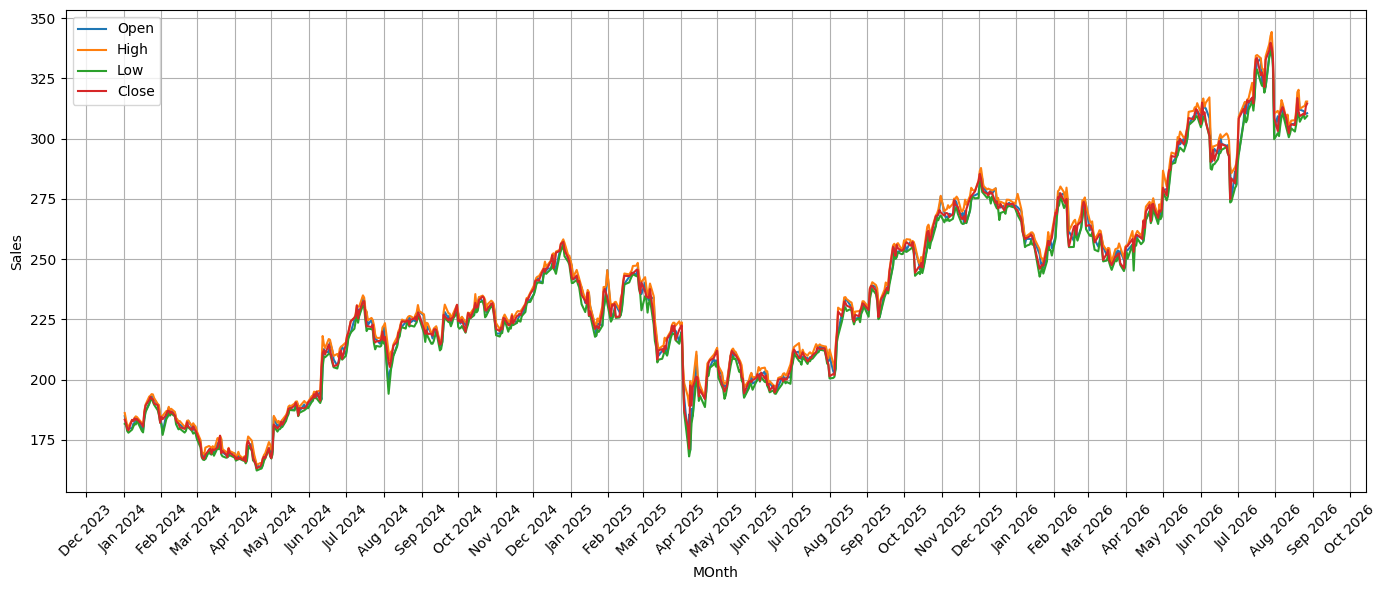

In [13]:
plt.figure(figsize=(14, 6))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(data.index, data[col], label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

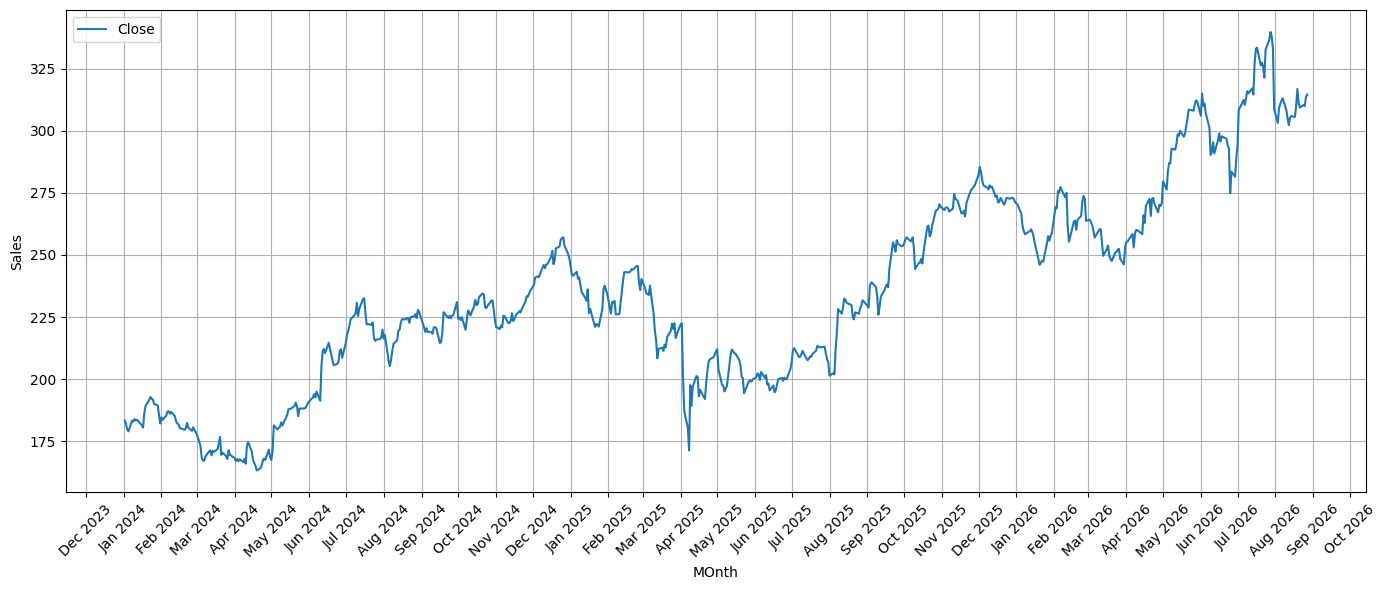

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df, label=col)
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('MOnth')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [16]:
import matplotlib.dates as mdates

<Figure size 1400x500 with 0 Axes>

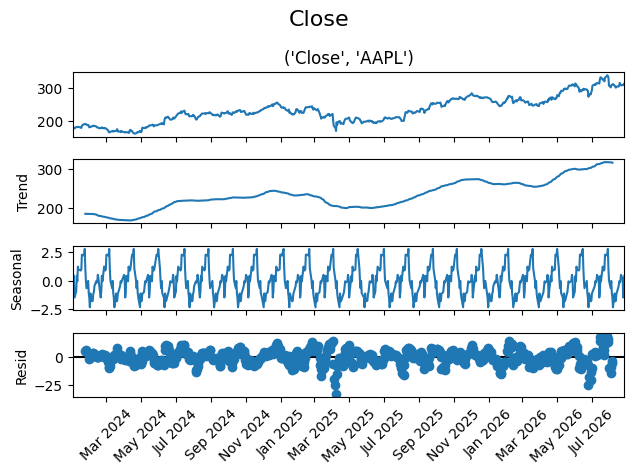

In [17]:

result=seasonal_decompose(
        df,model='additive',period=30)
fig=plt.figure(figsize=(14,5))
result.plot()
for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x',labelrotation=45)
plt.suptitle(col,fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
train_size = int(len(df) * 0.80)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [39]:
# For Holt's model, you will commonly encounter:

# Method	Meaning
# "estimated"	          Initial level and trend are estimated from the data
# "heuristic"	          Initial values are determined using a heuristic procedure
# "legacy-heuristic"	  Older/legacy heuristic approach
# "known"	              You provide the initial level and trend yourself

In [20]:
from statsmodels.tsa.holtwinters import Holt
model = Holt(
    train,
    initialization_method="estimated"
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [21]:
fit = model.fit(
    optimized=True
)

In [22]:

forecast = fit.forecast(len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
mae = mean_absolute_error(
    test,
    forecast
)

In [27]:
mae

26.110101006498336

In [28]:

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

In [29]:
rmse

np.float64(32.05708697317204)

In [30]:
mape = np.mean(np.abs((test.values - forecast.values) /test.values)) * 100

In [31]:
mape

np.float64(8.568279055992669)

In [32]:


print("\n===== MODEL PERFORMANCE =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)


===== MODEL PERFORMANCE =====
MAE  : 26.110101006498336
RMSE : 32.05708697317204
MAPE : 8.568279055992669


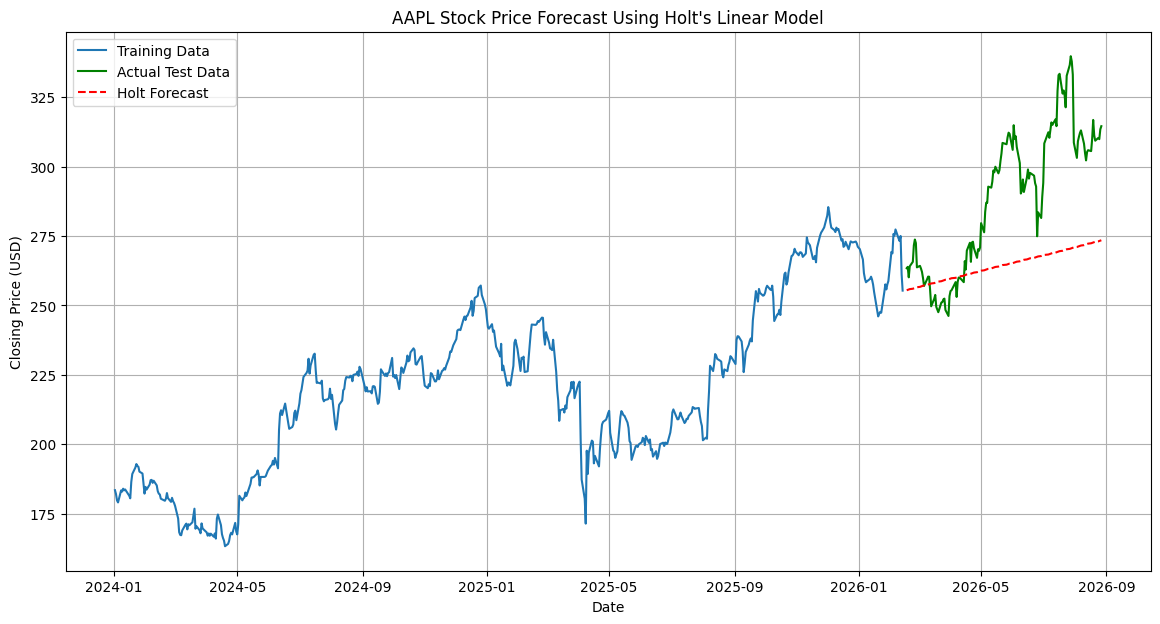

In [33]:
plt.figure(figsize=(14, 7))

plt.plot(train.index,train,   label="Training Data")
plt.plot(test.index,    test,    label="Actual Test Data",    color="green")
plt.plot(test.index,    forecast,    label="Holt Forecast",    color="red",    linestyle="--")
plt.title("AAPL Stock Price Forecast Using Holt's Linear Model")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()


In [35]:
final_model = Holt(
    df,
    initialization_method="estimated"
)

final_fit = final_model.fit(
    optimized=True
)
future_forecast = final_fit.forecast(30)

future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30
)

future_forecast.index = future_dates

print(future_forecast)


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2026-08-28    314.777245
2026-08-31    314.974504
2026-09-01    315.171762
2026-09-02    315.369020
2026-09-03    315.566279
2026-09-04    315.763537
2026-09-07    315.960796
2026-09-08    316.158054
2026-09-09    316.355313
2026-09-10    316.552571
2026-09-11    316.749830
2026-09-14    316.947088
2026-09-15    317.144347
2026-09-16    317.341605
2026-09-17    317.538864
2026-09-18    317.736122
2026-09-21    317.933381
2026-09-22    318.130639
2026-09-23    318.327898
2026-09-24    318.525156
2026-09-25    318.722415
2026-09-28    318.919673
2026-09-29    319.116932
2026-09-30    319.314190
2026-10-01    319.511449
2026-10-02    319.708707
2026-10-05    319.905966
2026-10-06    320.103224
2026-10-07    320.300482
2026-10-08    320.497741
Freq: B, dtype: float64


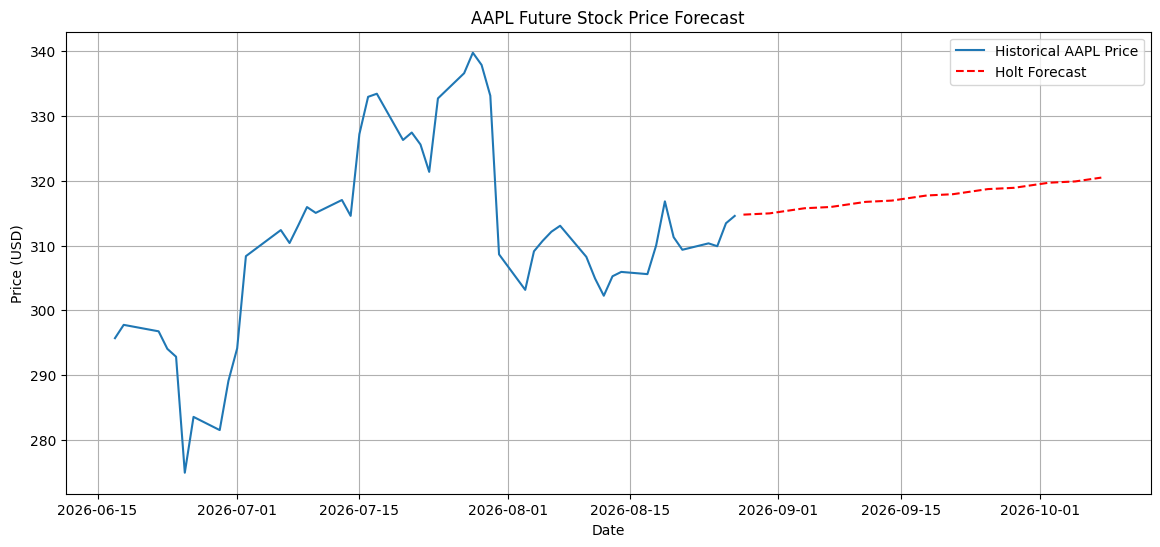

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.iloc[-50:],
    label="Historical AAPL Price"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    color="red",
    linestyle="--",
    label="Holt Forecast"
)

plt.title("AAPL Future Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# Damped Holt
model2 = Holt(
    train,
    damped_trend=True,
    initialization_method="estimated"
)

fit2 = model2.fit(optimized=True)
forecast2 = fit2.forecast(len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [38]:
mae = mean_absolute_error(
    test,
    forecast2
)
rmse = np.sqrt(
    mean_squared_error(test, forecast2)
)
mape = np.mean(np.abs((test.values - forecast2.values) /test.values)) * 100

In [39]:

print("\n===== MODEL PERFORMANCE =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)


===== MODEL PERFORMANCE =====
MAE  : 33.38991784753536
RMSE : 40.883573596722975
MAPE : 10.940309003380866


In [40]:
print(fit.params)

{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(183.26859243253563), 'initial_trend': np.float64(0.1354421929713895), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
